In [1]:
# WHAT: Install the libraries needed for the evaluation pipeline.
# WHY: We need Transformers to load the judge LLM and pandas to process
#      our existing Base/SFT/DPO evaluation results.

!pip install -q -U transformers accelerate bitsandbytes pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 84.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


## Evaluation Overview

**Goal:** Compare the Base, SFT, and DPO versions of the model.

We evaluate the models using multiple complementary metrics:

1. LLM-as-a-Judge scores
2. Pairwise preference / win rate
3. DPO-specific preference accuracy
4. Response-length statistics
5. Visualizations

**Important:** No training is performed in this notebook. The trained SFT and DPO adapters are loaded and evaluated.

In [2]:
# WHAT: Import the libraries and define paths used throughout the notebook.

import json
import re
import pandas as pd
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM

# Path to the evaluation results produced by Notebook 3
EVALUATION_RESULTS = "evaluation_results.csv"

# Output file for the LLM-as-a-Judge scores
JUDGE_RESULTS = "evaluation_judge_results.json"

# Your evaluation set
EVALUATION_QUESTIONS = "evaluation_questions.json"

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [3]:
# WHAT: Load the answers generated by Base, SFT and DPO.
# WHY: These are the responses that our independent judge will evaluate.

df = pd.read_csv(EVALUATION_RESULTS)

print("Number of evaluation questions:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst question:")
print(df.iloc[0]["question"])

print("\nBase answer:")
print(df.iloc[0]["base_model"])

print("\nSFT answer:")
print(df.iloc[0]["sft_model"])

print("\nDPO answer:")
print(df.iloc[0]["dpo_model"])

Number of evaluation questions: 49

Columns:
['question', 'base_model', 'sft_model', 'dpo_model']

First question:
What is a Large Language Model?

Base answer:
What is a Large Language Model? (LLM)

A Large Language Model (LLM) is a type of artificial intelligence (AI) model that is trained on a massive corpus of text data to generate human-like language. LLMs are designed to process and understand natural language, enabling them to perform a wide range of tasks, such as:

*   Text generation
*   Language translation
*   Sentiment analysis
*   Text summarization
*   Chatbots and conversational AI

**Key Characteristics of LLMs:**

1.  **Massive Training Data**: LLMs are trained on enormous amounts of text data, often in the order of billions of parameters.
2.  **Deep Neural Network Architecture**: LLMs are built using deep neural networks, which consist of multiple layers of interconnected nodes (neurons).
3.  **Self-Supervised Learning**: LLMs are typically trained using self-supervi

In [4]:
# WHAT: Choose a separate model to act as the evaluator.
# WHY: We don't want Base, SFT or DPO judging themselves.
#      An independent model gives us a less biased evaluation.

JUDGE_MODEL = "Qwen/Qwen2.5-3B-Instruct"

print("Judge model:", JUDGE_MODEL)

Judge model: Qwen/Qwen2.5-3B-Instruct


In [6]:
# WHAT: Load the independent LLM judge in 4-bit precision.
# WHY: 4-bit quantization reduces VRAM usage so the judge can run
#      on a Colab T4.

from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

judge_tokenizer = AutoTokenizer.from_pretrained(
    JUDGE_MODEL
)

judge_model = AutoModelForCausalLM.from_pretrained(
    JUDGE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
)

judge_model.eval()

print("Judge model loaded successfully.")

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Judge model loaded successfully.


## Step 1 — Load Evaluation Questions

We use a fixed set of evaluation questions that are separate from the training data.

**Why:** Using the same unseen questions for Base, SFT, and DPO makes the comparison fair.

In [7]:
# WHAT: Define the rubric used by the independent LLM judge.
# WHY: Every Base/SFT/DPO answer must be judged using exactly the same criteria.

JUDGE_SYSTEM_PROMPT = """
You are an impartial evaluator of answers produced by language models.

Evaluate the answer using the following four criteria:

1. Correctness:
   Is the answer factually accurate and free from important technical errors?

2. Relevance:
   Does the answer directly address the question without unnecessary information?

3. Clarity:
   Is the explanation easy to understand, well-organized, and unambiguous?

4. Helpfulness:
   Does the answer actually help the user understand or solve what they asked?

Give each criterion a score from 1 to 5:

1 = Very poor
2 = Poor
3 = Acceptable
4 = Good
5 = Excellent

Return ONLY valid JSON in exactly this format:

{
  "correctness": <1-5>,
  "relevance": <1-5>,
  "clarity": <1-5>,
  "helpfulness": <1-5>,
  "overall": <1-5>,
  "reason": "<brief explanation>"
}

Do not use markdown.
"""

print(JUDGE_SYSTEM_PROMPT)


You are an impartial evaluator of answers produced by language models.

Evaluate the answer using the following four criteria:

1. Correctness:
   Is the answer factually accurate and free from important technical errors?

2. Relevance:
   Does the answer directly address the question without unnecessary information?

3. Clarity:
   Is the explanation easy to understand, well-organized, and unambiguous?

4. Helpfulness:
   Does the answer actually help the user understand or solve what they asked?

Give each criterion a score from 1 to 5:

1 = Very poor
2 = Poor
3 = Acceptable
4 = Good
5 = Excellent

Return ONLY valid JSON in exactly this format:

{
  "correctness": <1-5>,
  "relevance": <1-5>,
  "clarity": <1-5>,
  "helpfulness": <1-5>,
  "overall": <1-5>,
  "reason": "<brief explanation>"
}

Do not use markdown.



In [10]:
# WHAT: Send one question + one model answer to the independent LLM judge.
# WHY: Test one evaluation before running the full evaluation set.

def judge_answer(question, answer):

    prompt = f"""
Question:
{question}

Answer to evaluate:
{answer}

Evaluate this answer using the rubric provided in the system message.
Return ONLY the requested JSON.
"""

    messages = [
        {"role": "system", "content": JUDGE_SYSTEM_PROMPT},
        {"role": "user", "content": prompt},
    ]

    # First create the chat-formatted text
    chat_text = judge_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    # Then tokenize it explicitly
    inputs = judge_tokenizer(
        chat_text,
        return_tensors="pt"
    ).to(judge_model.device)

    with torch.no_grad():
        outputs = judge_model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False,
            pad_token_id=judge_tokenizer.eos_token_id,
        )

    # Remove the original prompt tokens.
    input_length = inputs["input_ids"].shape[1]
    generated_tokens = outputs[0][input_length:]

    result = judge_tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return result.strip()

## Step 2 — Generate Responses

For every evaluation question, we generate three responses:

**Base → SFT → DPO**

The same question and generation settings are used for all three models.

`do_sample=False` is used so that the evaluation is deterministic and reproducible.

In [11]:
# WHAT: Test the judge on one existing SFT response.
# WHY: Make sure the judge produces the expected JSON before evaluating
#      the entire dataset.

test_question = df.iloc[0]["question"]
test_answer = df.iloc[0]["sft_model"]

judge_output = judge_answer(
    test_question,
    test_answer
)

print("QUESTION:")
print(test_question)

print("\nSFT ANSWER:")
print(test_answer)

print("\nJUDGE OUTPUT:")
print(judge_output)

QUESTION:
What is a Large Language Model?

SFT ANSWER:
What is a Large Language Model? (LLM)

A Large Language Model (LLM) is a type of machine learning model that is trained on vast amounts of text data to generate human-like language. LLMs are designed to predict the next word in a sequence of text, given the context of the previous words. This prediction process allows LLMs to generate coherent and context-dependent text.

Key Components of LLMs
------------------------

*   **Training Data**: LLMs are trained on massive amounts of text data, which can include books, articles, conversations, and other forms of written language.
*   **Model Architecture**: LLMs typically consist of transformer-based neural networks, which are designed to handle sequential data like text.
*   **Tokenization**: Text is broken down into individual tokens, such as words or subwords, which are used as input to the model.
*   **Training Objective**: LLMs are trained using a combination of supervised and re

In [12]:
# WHAT: Convert the judge's text response into a Python dictionary.
# WHY: We need numerical scores to calculate averages and compare
#      Base vs SFT vs DPO.

def parse_judge_output(text):
    try:
        # Find the JSON object even if the model accidentally adds
        # a little extra text around it.
        match = re.search(r"\{.*\}", text, re.DOTALL)

        if not match:
            return None

        return json.loads(match.group(0))

    except (json.JSONDecodeError, TypeError):
        return None


test_scores = parse_judge_output(judge_output)

print(test_scores)

{'correctness': 5, 'relevance': 5, 'clarity': 4, 'helpfulness': 4, 'overall': 4, 'reason': 'The answer is clear and provides relevant information about Large Language Models. It covers key components and training aspects but could be more concise.'}


In [13]:
# WHAT: Validate the judge response.
# WHY: Prevent malformed judge outputs from silently entering our results.

required_keys = [
    "correctness",
    "relevance",
    "clarity",
    "helpfulness",
    "overall",
    "reason",
]

if test_scores is not None and all(
    key in test_scores for key in required_keys
):
    print("Judge output is valid.")
else:
    print("Judge output is missing required fields.")
    print("Raw output:")
    print(judge_output)

Judge output is valid.


## Step 3 — Basic Response Statistics

We calculate the average response length for Base, SFT, and DPO.

**Why:** Response length is not a quality metric, but it provides a basic descriptive comparison of the generated outputs.

In [14]:
# WHAT: Run the LLM judge on every answer from Base, SFT and DPO.
# WHY: We need comparable scores for all three stages.

evaluation_results = []

for i, row in df.iterrows():

    question = row["question"]

    # Judge Base
    base_judge = parse_judge_output(
        judge_answer(question, row["base_model"])
    )

    # Judge SFT
    sft_judge = parse_judge_output(
        judge_answer(question, row["sft_model"])
    )

    # Judge DPO
    dpo_judge = parse_judge_output(
        judge_answer(question, row["dpo_model"])
    )

    evaluation_results.append({
        "question": question,

        "base_correctness": base_judge["correctness"],
        "base_relevance": base_judge["relevance"],
        "base_clarity": base_judge["clarity"],
        "base_helpfulness": base_judge["helpfulness"],
        "base_overall": base_judge["overall"],

        "sft_correctness": sft_judge["correctness"],
        "sft_relevance": sft_judge["relevance"],
        "sft_clarity": sft_judge["clarity"],
        "sft_helpfulness": sft_judge["helpfulness"],
        "sft_overall": sft_judge["overall"],

        "dpo_correctness": dpo_judge["correctness"],
        "dpo_relevance": dpo_judge["relevance"],
        "dpo_clarity": dpo_judge["clarity"],
        "dpo_helpfulness": dpo_judge["helpfulness"],
        "dpo_overall": dpo_judge["overall"],
    })

    print(f"Done {i + 1}/{len(df)}")

Done 1/49
Done 2/49
Done 3/49
Done 4/49
Done 5/49
Done 6/49
Done 7/49
Done 8/49
Done 9/49
Done 10/49
Done 11/49
Done 12/49
Done 13/49
Done 14/49
Done 15/49
Done 16/49
Done 17/49
Done 18/49
Done 19/49
Done 20/49
Done 21/49
Done 22/49
Done 23/49
Done 24/49
Done 25/49
Done 26/49
Done 27/49
Done 28/49
Done 29/49
Done 30/49
Done 31/49
Done 32/49
Done 33/49
Done 34/49
Done 35/49
Done 36/49
Done 37/49
Done 38/49
Done 39/49
Done 40/49
Done 41/49
Done 42/49
Done 43/49
Done 44/49
Done 45/49
Done 46/49
Done 47/49
Done 48/49
Done 49/49


In [15]:
# WHAT: Convert all judge scores into a DataFrame.
# WHY: Makes the results easy to analyze and visualize.

judge_df = pd.DataFrame(evaluation_results)

print("Evaluation completed.")
print("Shape:", judge_df.shape)

display(judge_df.head())

Evaluation completed.
Shape: (49, 16)


,question,base_correctness,base_relevance,base_clarity,base_helpfulness,base_overall,sft_correctness,sft_relevance,sft_clarity,sft_helpfulness,sft_overall,dpo_correctness,dpo_relevance,dpo_clarity,dpo_helpfulness,dpo_overall
0,What is a Large Language Model?,5,5,5,5,5,5,5,4,4,4,5,5,5,5,5
1,Explain how tokenization works in LLMs.,4,5,4,3,4,4,5,4,3,4,4,5,4,3,4
2,What are embeddings and why are they important?,3,4,3,3,3,5,5,4,5,5,5,5,5,5,5
3,Explain the Transformer architecture.,5,5,4,4,4,5,5,5,5,5,5,5,5,5,5
4,What is self-attention?,5,5,5,5,5,5,5,5,5,5,4,5,4,4,4


In [16]:
# WHAT: Calculate average evaluation scores for each model.
# WHY: Shows whether the model improves from Base → SFT → DPO.

metrics = [
    "correctness",
    "relevance",
    "clarity",
    "helpfulness",
    "overall",
]

average_scores = pd.DataFrame({
    "Base": [
        judge_df[f"base_{m}"].mean() for m in metrics
    ],
    "SFT": [
        judge_df[f"sft_{m}"].mean() for m in metrics
    ],
    "DPO": [
        judge_df[f"dpo_{m}"].mean() for m in metrics
    ],
}, index=metrics)

print(average_scores.round(2))

             Base   SFT   DPO
correctness  3.65  4.08  4.12
relevance    4.22  4.45  4.49
clarity      3.59  4.10  4.16
helpfulness  3.47  3.98  4.06
overall      3.61  4.10  4.14


In [17]:
# WHAT: Determine which model has the highest overall judge score
#       for each evaluation question.
# WHY: This lets us calculate how often SFT/DPO wins against Base
#       and against each other.

def get_winner(row):
    scores = {
        "Base": row["base_overall"],
        "SFT": row["sft_overall"],
        "DPO": row["dpo_overall"],
    }

    return max(scores, key=scores.get)


judge_df["winner"] = judge_df.apply(get_winner, axis=1)

print(judge_df["winner"].value_counts())

winner
Base    23
SFT     20
DPO      6
Name: count, dtype: int64


In [18]:
# WHAT: Calculate the percentage of questions won by each model.
# WHY: A win rate gives an easy-to-understand comparison for the presentation.

win_rates = (
    judge_df["winner"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(["Base", "SFT", "DPO"], fill_value=0)
)

print("Preference Win Rate:")
print(win_rates.round(2))

Preference Win Rate:
winner
Base    46.94
SFT     40.82
DPO     12.24
Name: proportion, dtype: float64


## Step 4 — LLM-as-a-Judge

An external language model is used as an automatic evaluator.

Instead of manually judging every answer, the judge scores each response using the same rubric.

We evaluate:

- Correctness
- Relevance
- Clarity
- Helpfulness
- Overall quality

Each criterion is scored from **1 to 5**.

In [19]:
# WHAT: Compare two model answers directly for the same question.
# WHY: Pairwise comparison is a better way to measure preference win rate.

PAIRWISE_SYSTEM_PROMPT = """
You are an impartial evaluator comparing two answers to the same question.

Choose which answer is better based on:
- correctness
- relevance
- clarity
- helpfulness

Do not prefer an answer simply because it is longer.

Return ONLY valid JSON in exactly this format:

{
  "winner": "A",
  "reason": "brief explanation"
}

The winner must be exactly "A", "B", or "Tie".
"""

def pairwise_judge(question, answer_a, answer_b):

    prompt = f"""
Question:
{question}

Answer A:
{answer_a}

Answer B:
{answer_b}

Which answer is better overall?
"""

    messages = [
        {"role": "system", "content": PAIRWISE_SYSTEM_PROMPT},
        {"role": "user", "content": prompt},
    ]

    chat_text = judge_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = judge_tokenizer(
        chat_text,
        return_tensors="pt"
    ).to(judge_model.device)

    with torch.no_grad():
        outputs = judge_model.generate(
            **inputs,
            max_new_tokens=100,
            do_sample=False,
            pad_token_id=judge_tokenizer.eos_token_id,
        )

    input_length = inputs["input_ids"].shape[1]

    generated_tokens = outputs[0][input_length:]

    result = judge_tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    return result.strip()

In [20]:
test_question = df.iloc[0]["question"]

pairwise_output = pairwise_judge(
    test_question,
    df.iloc[0]["sft_model"],
    df.iloc[0]["dpo_model"]
)

print("QUESTION:")
print(test_question)

print("\nPAIRWISE JUDGE:")
print(pairwise_output)

QUESTION:
What is a Large Language Model?

PAIRWISE JUDGE:
{
  "winner": "A",
  "reason": "Answer A provides additional information about key components and how LLMs work, making it more comprehensive and detailed."
}


In [21]:
# WHAT: Compare SFT and DPO directly on every held-out question.
# WHY: Measures how often DPO is preferred over the SFT model.

sft_vs_dpo = []

for i, row in df.iterrows():

    result = pairwise_judge(
        row["question"],
        row["sft_model"],   # Answer A
        row["dpo_model"]    # Answer B
    )

    sft_vs_dpo.append({
        "question": row["question"],
        "judge_output": result
    })

    print(f"Done {i + 1}/{len(df)}")

Done 1/49
Done 2/49
Done 3/49
Done 4/49
Done 5/49
Done 6/49
Done 7/49
Done 8/49
Done 9/49
Done 10/49
Done 11/49
Done 12/49
Done 13/49
Done 14/49
Done 15/49
Done 16/49
Done 17/49
Done 18/49
Done 19/49
Done 20/49
Done 21/49
Done 22/49
Done 23/49
Done 24/49
Done 25/49
Done 26/49
Done 27/49
Done 28/49
Done 29/49
Done 30/49
Done 31/49
Done 32/49
Done 33/49
Done 34/49
Done 35/49
Done 36/49
Done 37/49
Done 38/49
Done 39/49
Done 40/49
Done 41/49
Done 42/49
Done 43/49
Done 44/49
Done 45/49
Done 46/49
Done 47/49
Done 48/49
Done 49/49


## Step 5 — Calculate Average Judge Scores

We calculate the mean score across the evaluation questions for Base, SFT, and DPO.

This gives us an overall quantitative view of response quality.

The main comparison is:

**Base → SFT → DPO**

In [22]:
import json

def extract_winner(text):
    try:
        data = json.loads(text)
        winner = data.get("winner", "Invalid")

        if winner in ["A", "B", "Tie"]:
            return winner

        return "Invalid"

    except Exception:
        return "Invalid"


sft_dpo_df = pd.DataFrame(sft_vs_dpo)

sft_dpo_df["winner"] = sft_dpo_df["judge_output"].apply(
    extract_winner
)

print(sft_dpo_df["winner"].value_counts())

winner
B      27
A      20
Tie     2
Name: count, dtype: int64


In [23]:
valid = sft_dpo_df[
    sft_dpo_df["winner"].isin(["A", "B", "Tie"])
]

dpo_wins = (valid["winner"] == "B").sum()
sft_wins = (valid["winner"] == "A").sum()
ties = (valid["winner"] == "Tie").sum()

total = len(valid)

print(f"SFT wins: {sft_wins} ({sft_wins/total*100:.2f}%)")
print(f"DPO wins: {dpo_wins} ({dpo_wins/total*100:.2f}%)")
print(f"Ties:     {ties} ({ties/total*100:.2f}%)")

SFT wins: 20 (40.82%)
DPO wins: 27 (55.10%)
Ties:     2 (4.08%)


In [24]:
# WHAT: Compare Base and SFT directly on every held-out question.
# WHY: Measures the improvement produced by SFT.

base_vs_sft = []

for i, row in df.iterrows():

    result = pairwise_judge(
        row["question"],
        row["base_model"],   # Answer A
        row["sft_model"]     # Answer B
    )

    base_vs_sft.append({
        "question": row["question"],
        "judge_output": result
    })

    print(f"Done {i + 1}/{len(df)}")

Done 1/49
Done 2/49
Done 3/49
Done 4/49
Done 5/49
Done 6/49
Done 7/49
Done 8/49
Done 9/49
Done 10/49
Done 11/49
Done 12/49
Done 13/49
Done 14/49
Done 15/49
Done 16/49
Done 17/49
Done 18/49
Done 19/49
Done 20/49
Done 21/49
Done 22/49
Done 23/49
Done 24/49
Done 25/49
Done 26/49
Done 27/49
Done 28/49
Done 29/49
Done 30/49
Done 31/49
Done 32/49
Done 33/49
Done 34/49
Done 35/49
Done 36/49
Done 37/49
Done 38/49
Done 39/49
Done 40/49
Done 41/49
Done 42/49
Done 43/49
Done 44/49
Done 45/49
Done 46/49
Done 47/49
Done 48/49
Done 49/49


In [25]:
base_sft_df = pd.DataFrame(base_vs_sft)

base_sft_df["winner"] = base_sft_df["judge_output"].apply(
    extract_winner
)

print(base_sft_df["winner"].value_counts())

winner
B    40
A     9
Name: count, dtype: int64


In [26]:
valid = base_sft_df[
    base_sft_df["winner"].isin(["A", "B", "Tie"])
]

base_wins = (valid["winner"] == "A").sum()
sft_wins = (valid["winner"] == "B").sum()
ties = (valid["winner"] == "Tie").sum()

total = len(valid)

print(f"Base wins: {base_wins} ({base_wins/total*100:.2f}%)")
print(f"SFT wins:  {sft_wins} ({sft_wins/total*100:.2f}%)")
print(f"Ties:      {ties} ({ties/total*100:.2f}%)")

Base wins: 9 (18.37%)
SFT wins:  40 (81.63%)
Ties:      0 (0.00%)


## Step 6 — Pairwise Preference Evaluation

Here the judge directly compares two responses to the same question.

We perform three comparisons:

- Base vs SFT
- SFT vs DPO
- Base vs DPO

The judge selects the preferred response or declares a tie.

**Why:** Pairwise evaluation directly measures which model produces the better answer.

In [27]:
# WHAT: Compare Base and DPO directly.
# WHY: Measures the overall effect of the complete post-training pipeline.

base_vs_dpo = []

for i, row in df.iterrows():

    result = pairwise_judge(
        row["question"],
        row["base_model"],   # Answer A
        row["dpo_model"]     # Answer B
    )

    base_vs_dpo.append({
        "question": row["question"],
        "judge_output": result
    })

    print(f"Done {i + 1}/{len(df)}")

Done 1/49
Done 2/49
Done 3/49
Done 4/49
Done 5/49
Done 6/49
Done 7/49
Done 8/49
Done 9/49
Done 10/49
Done 11/49
Done 12/49
Done 13/49
Done 14/49
Done 15/49
Done 16/49
Done 17/49
Done 18/49
Done 19/49
Done 20/49
Done 21/49
Done 22/49
Done 23/49
Done 24/49
Done 25/49
Done 26/49
Done 27/49
Done 28/49
Done 29/49
Done 30/49
Done 31/49
Done 32/49
Done 33/49
Done 34/49
Done 35/49
Done 36/49
Done 37/49
Done 38/49
Done 39/49
Done 40/49
Done 41/49
Done 42/49
Done 43/49
Done 44/49
Done 45/49
Done 46/49
Done 47/49
Done 48/49
Done 49/49


In [28]:
base_dpo_df = pd.DataFrame(base_vs_dpo)

base_dpo_df["winner"] = base_dpo_df["judge_output"].apply(
    extract_winner
)

print(base_dpo_df["winner"].value_counts())

winner
B    40
A     9
Name: count, dtype: int64


In [29]:
# WHAT: Combine all pairwise comparisons into one summary table.
# WHY: Gives one clear view of Base → SFT → DPO progression.

def get_pairwise_stats(result_df, model_a, model_b):
    valid = result_df[
        result_df["winner"].isin(["A", "B", "Tie"])
    ]

    total = len(valid)

    a_wins = (valid["winner"] == "A").sum()
    b_wins = (valid["winner"] == "B").sum()
    ties = (valid["winner"] == "Tie").sum()

    return {
        "Comparison": f"{model_a} vs {model_b}",
        f"{model_a} Win %": round(a_wins / total * 100, 2),
        f"{model_b} Win %": round(b_wins / total * 100, 2),
        "Tie %": round(ties / total * 100, 2),
    }


pairwise_summary = pd.DataFrame([
    get_pairwise_stats(
        base_sft_df,
        "Base",
        "SFT"
    ),
    get_pairwise_stats(
        sft_dpo_df,
        "SFT",
        "DPO"
    ),
    get_pairwise_stats(
        base_dpo_df,
        "Base",
        "DPO"
    )
])

display(pairwise_summary)

,Comparison,Base Win %,SFT Win %,Tie %,DPO Win %
0,Base vs SFT,18.37,81.63,0.00,NaN
1,SFT vs DPO,NaN,40.82,4.08,55.10
2,Base vs DPO,18.37,NaN,0.00,81.63


In [30]:
# WHAT: Save the evaluation results so they can be reused later.
# WHY: Avoids having to run the LLM judge again.

import os

os.makedirs("outputs", exist_ok=True)

judge_df.to_csv(
    "outputs/llm_judge_scores.csv",
    index=False
)

base_sft_df.to_csv(
    "outputs/pairwise_base_vs_sft.csv",
    index=False
)

sft_dpo_df.to_csv(
    "outputs/pairwise_sft_vs_dpo.csv",
    index=False
)

base_dpo_df.to_csv(
    "outputs/pairwise_base_vs_dpo.csv",
    index=False
)

pairwise_summary.to_csv(
    "outputs/pairwise_summary.csv",
    index=False
)

print("All evaluation results saved.")

All evaluation results saved.


## Step 7 — Calculate Preference Win Rates

We convert the pairwise results into percentages.

A higher win rate means the model was preferred more often by the judge.

This allows us to see whether the progression

**Base → SFT → DPO**

also appears in direct model-to-model comparisons.

In [31]:
# WHAT: Create a compact final score table.
# WHY: Makes Base vs SFT vs DPO easy to present.

final_scores = average_scores.T.copy()

final_scores = final_scores.round(2)

display(final_scores)

,correctness,relevance,clarity,helpfulness,overall
Base,3.65,4.22,3.59,3.47,3.61
SFT,4.08,4.45,4.10,3.98,4.10
DPO,4.12,4.49,4.16,4.06,4.14


In [32]:
# WHAT: Identify which checkpoint scored highest for each metric.
# WHY: Shows where each training stage helped most.

best_models = final_scores.idxmax()

print("Best model by metric:\n")
print(best_models)

Best model by metric:

correctness    DPO
relevance      DPO
clarity        DPO
helpfulness    DPO
overall        DPO
dtype: str


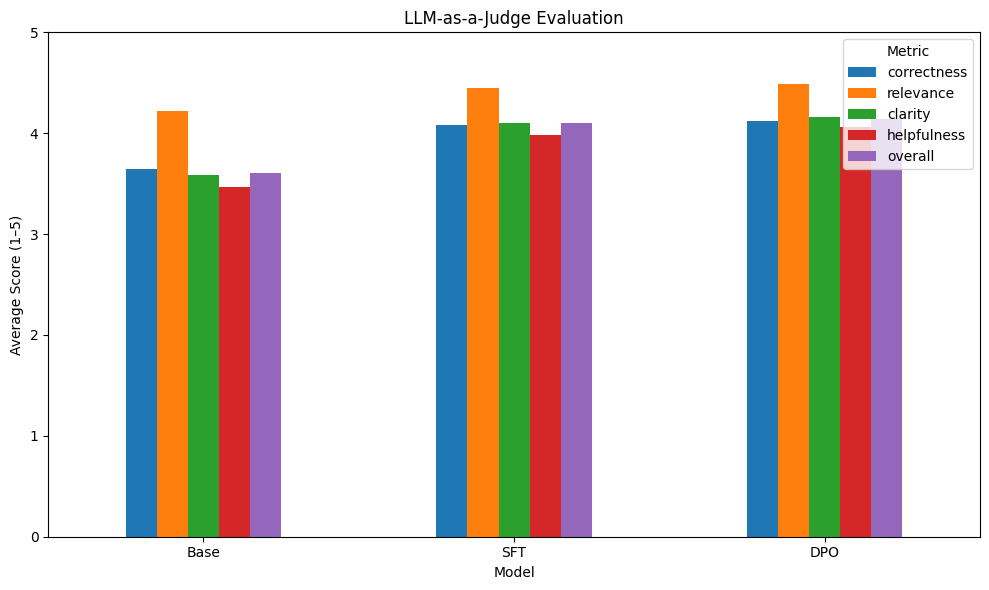

In [33]:
import matplotlib.pyplot as plt

# WHAT: Plot average judge scores for Base, SFT and DPO.
# WHY: Makes the improvement/differences easy to show in the presentation.

metrics = [
    "correctness",
    "relevance",
    "clarity",
    "helpfulness",
    "overall"
]

final_scores[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("LLM-as-a-Judge Evaluation")
plt.xlabel("Model")
plt.ylabel("Average Score (1–5)")
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

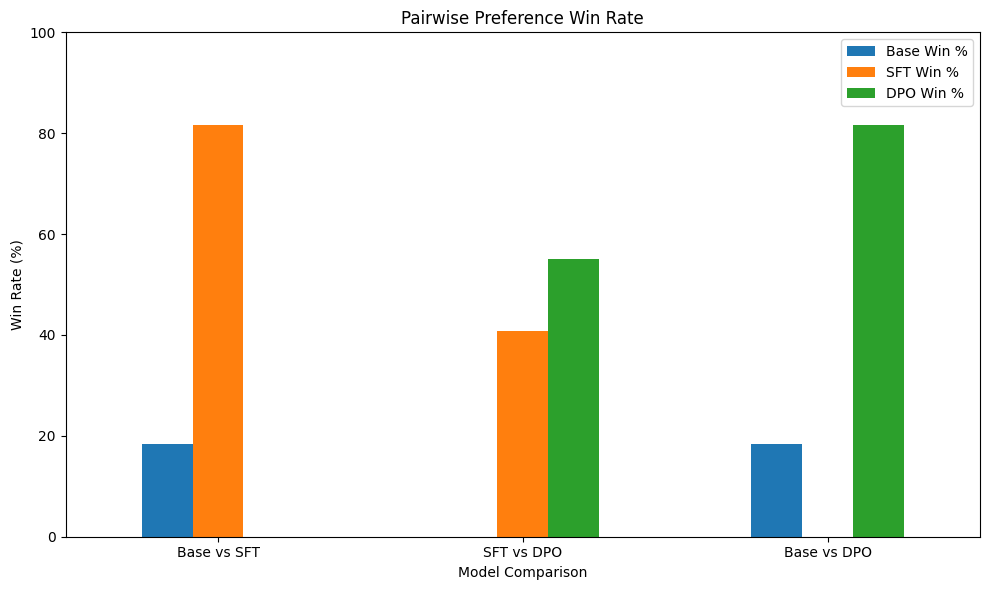

In [34]:
# WHAT: Visualize pairwise preference results.
# WHY: Shows which model is preferred directly against another model.

plot_data = pairwise_summary.set_index("Comparison")

plot_data[
    [col for col in plot_data.columns if "Win %" in col]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Pairwise Preference Win Rate")
plt.xlabel("Model Comparison")
plt.ylabel("Win Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
# WHAT: Load the NEW preference pairs that were never used for DPO training.
# WHY: This gives us a genuinely held-out test set for DPO evaluation.

dpo_eval_rows = load_jsonl("dpo_eval_preferences.jsonl")

print(f"Loaded {len(dpo_eval_rows)} held-out preference pairs")
print("\nFirst example:")
print(dpo_eval_rows[0])

Loaded 31 held-out preference pairs

First example:
{'prompt': 'What is continued pretraining?', 'chosen': 'Continued pretraining further trains an existing pretrained language model on additional domain-specific or specialized text. It can help the model learn new vocabulary, concepts, and domain patterns before instruction tuning.', 'rejected': 'Continued pretraining means restarting the entire model from random weights and training it from scratch on a completely new dataset.'}


## Step 8 — DPO-Specific Preference Evaluation

We now perform a more direct test of preference learning.

A new held-out dataset containing **31 preference pairs** is used.

Each pair contains:

- Prompt
- Chosen response
- Rejected response

These pairs were **not used during DPO training**.

**Goal:** Check whether each model assigns a higher probability to the chosen response than to the rejected response.

In [39]:
# WHAT: Check that every example has the three fields required for DPO evaluation.
# WHY: Prevents formatting errors later.

required_fields = {"prompt", "chosen", "rejected"}

valid = all(
    required_fields.issubset(row.keys())
    for row in dpo_eval_rows
)

print("Dataset format valid:", valid)
print("Number of pairs:", len(dpo_eval_rows))

Dataset format valid: True
Number of pairs: 31


In [43]:
!pip install -q -U "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 22.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account al

In [44]:
from unsloth import FastLanguageModel
import torch

print("Unsloth imported successfully!")

/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:1531: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth imported successfully!


In [47]:
# WHAT: Load the frozen 4-bit base model and attach the
#       SFT and DPO LoRA adapters from Hugging Face.
# WHY: We need all three model states for preference evaluation.

from unsloth import FastLanguageModel

MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
MAX_SEQ_LENGTH = 2048

SFT_ADAPTER = "Hiteshwari7/posttraining-tutor-sft-adapter"

# CHANGE THIS to your actual DPO adapter Hugging Face repo
DPO_ADAPTER = "Hiteshwari7/postraining-tutor-dpo-adapter"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

# Attach both adapters
model.load_adapter(
    SFT_ADAPTER,
    adapter_name="sft"
)

model.load_adapter(
    DPO_ADAPTER,
    adapter_name="dpo"
)

# Switch to inference mode
FastLanguageModel.for_inference(model)

print("Base model loaded.")
print("SFT adapter loaded.")
print("DPO adapter loaded.")
print("Ready for DPO preference evaluation.")

==((====))==  Unsloth 2026.8.13: Fast Llama patching. Transformers: 5.15.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.


Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

adapter_config.json:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

...

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B / 97.3MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

LlamaForCausalLM LOAD REPORT from: Hiteshwari7/postraining-tutor-dpo-adapter
Key                                                      | Status  | 
---------------------------------------------------------+---------+-
model.layers.{0...27}.self_attn.v_proj.lora_A.sft.weight | MISSING | 
model.layers.{0...27}.self_attn.o_proj.lora_B.sft.weight | MISSING | 
model.layers.{0...27}.self_attn.k_proj.lora_A.sft.weight | MISSING | 
model.layers.{0...27}.self_attn.v_proj.lora_B.sft.weight | MISSING | 
model.layers.{0...27}.mlp.gate_proj.lora_A.sft.weight    | MISSING | 
model.layers.{0...27}.mlp.down_proj.lora_B.sft.weight    | MISSING | 
model.layers.{0...27}.mlp.up_proj.lora_A.sft.weight      | MISSING | 
model.layers.{0...27}.self_attn.k_proj.lora_B.sft.weight | MISSING | 
model.layers.{0...27}.self_attn.o_proj.lora_A.sft.weight | MISSING | 
model.layers.{0...27}.mlp.gate_proj.lora_B.sft.weight    | MISSING | 
model.layers.{0...27}.self_attn.q_proj.lora_B.sft.weight | MISSING | 
model.layers.

Base model loaded.
SFT adapter loaded.
DPO adapter loaded.
Ready for DPO preference evaluation.


## Step 9 — Calculate Response Log-Probabilities

For each prompt, we calculate the model's log-probability for:

**Chosen response**

and

**Rejected response**

If:

`log P(chosen) > log P(rejected)`

then the model correctly predicts the preferred response.

This is a model-based preference test rather than an LLM-judge score.

In [49]:
# System prompt used during SFT/DPO training.
SYSTEM_PROMPT = (
    "You are PostTraining Tutor, an assistant that explains LLM training "
    "concepts (Transformers, LoRA, QLoRA, SFT, DPO, RLHF, alignment) "
    "clearly and concisely."
)

print("SYSTEM_PROMPT loaded.")

SYSTEM_PROMPT loaded.


In [50]:
# WHAT: Test the probability calculation on one unseen preference pair.
# WHY: Verify everything works before processing all 31 pairs.

test_pair = dpo_eval_rows[0]

prompt = test_pair["prompt"]
chosen = test_pair["chosen"]
rejected = test_pair["rejected"]

print("Prompt:")
print(prompt)

print("\nChosen:")
print(chosen)

print("\nRejected:")
print(rejected)

print("\n--- Log probabilities ---")

base_chosen = get_response_logprob(
    model, tokenizer, prompt, chosen, None
)

base_rejected = get_response_logprob(
    model, tokenizer, prompt, rejected, None
)

sft_chosen = get_response_logprob(
    model, tokenizer, prompt, chosen, "sft"
)

sft_rejected = get_response_logprob(
    model, tokenizer, prompt, rejected, "sft"
)

dpo_chosen = get_response_logprob(
    model, tokenizer, prompt, chosen, "dpo"
)

dpo_rejected = get_response_logprob(
    model, tokenizer, prompt, rejected, "dpo"
)

print(f"Base — chosen:   {base_chosen:.2f}")
print(f"Base — rejected: {base_rejected:.2f}")

print(f"SFT  — chosen:   {sft_chosen:.2f}")
print(f"SFT  — rejected: {sft_rejected:.2f}")

print(f"DPO  — chosen:   {dpo_chosen:.2f}")
print(f"DPO  — rejected: {dpo_rejected:.2f}")

`use_return_dict` is deprecated! Use `return_dict` instead!


Prompt:
What is continued pretraining?

Chosen:
Continued pretraining further trains an existing pretrained language model on additional domain-specific or specialized text. It can help the model learn new vocabulary, concepts, and domain patterns before instruction tuning.

Rejected:
Continued pretraining means restarting the entire model from random weights and training it from scratch on a completely new dataset.

--- Log probabilities ---
Base — chosen:   -124.44
Base — rejected: -62.66
SFT  — chosen:   -85.50
SFT  — rejected: -48.03
DPO  — chosen:   -85.00
DPO  — rejected: -49.00


In [51]:
# WHAT: Check whether each model gives the chosen response
#       a higher log-probability than the rejected response.

print("\nPreference prediction:")

print(
    "Base:",
    "CHOSEN" if base_chosen > base_rejected else "REJECTED"
)

print(
    "SFT:",
    "CHOSEN" if sft_chosen > sft_rejected else "REJECTED"
)

print(
    "DPO:",
    "CHOSEN" if dpo_chosen > dpo_rejected else "REJECTED"
)


Preference prediction:
Base: REJECTED
SFT: REJECTED
DPO: REJECTED


## Step 10 — Evaluate All 31 Held-Out Pairs

The same chosen-vs-rejected probability comparison is repeated for all 31 unseen preference pairs.

Testing multiple pairs gives us an overall preference accuracy rather than relying on a single example.

In [52]:
# WHAT: Evaluate all 31 unseen preference pairs.
# WHY: Aggregate accuracy is much more meaningful than one example.

dpo_preference_results = []

for i, pair in enumerate(dpo_eval_rows, 1):

    prompt = pair["prompt"]
    chosen = pair["chosen"]
    rejected = pair["rejected"]

    # Base
    base_chosen = get_response_logprob(
        model, tokenizer, prompt, chosen, None
    )

    base_rejected = get_response_logprob(
        model, tokenizer, prompt, rejected, None
    )

    # SFT
    sft_chosen = get_response_logprob(
        model, tokenizer, prompt, chosen, "sft"
    )

    sft_rejected = get_response_logprob(
        model, tokenizer, prompt, rejected, "sft"
    )

    # DPO
    dpo_chosen = get_response_logprob(
        model, tokenizer, prompt, chosen, "dpo"
    )

    dpo_rejected = get_response_logprob(
        model, tokenizer, prompt, rejected, "dpo"
    )

    dpo_preference_results.append({
        "prompt": prompt,

        "base_chosen_logprob": base_chosen,
        "base_rejected_logprob": base_rejected,

        "sft_chosen_logprob": sft_chosen,
        "sft_rejected_logprob": sft_rejected,

        "dpo_chosen_logprob": dpo_chosen,
        "dpo_rejected_logprob": dpo_rejected,
    })

    print(f"Done {i}/{len(dpo_eval_rows)}")

Done 1/31
Done 2/31
Done 3/31
Done 4/31
Done 5/31
Done 6/31
Done 7/31
Done 8/31
Done 9/31
Done 10/31
Done 11/31
Done 12/31
Done 13/31
Done 14/31
Done 15/31
Done 16/31
Done 17/31
Done 18/31
Done 19/31
Done 20/31
Done 21/31
Done 22/31
Done 23/31
Done 24/31
Done 25/31
Done 26/31
Done 27/31
Done 28/31
Done 29/31
Done 30/31
Done 31/31


## Step 11 — DPO Preference Accuracy

We calculate the percentage of held-out preference pairs where each model correctly prefers the chosen response.

**Preference Accuracy = Correct predictions / Total pairs × 100**

This gives us a direct model-based measure of preference learning.

In [53]:
# WHAT: Determine whether each model assigns higher probability
#       to the chosen response.
# WHY: This is our DPO-specific preference accuracy metric.

dpo_pref_df = pd.DataFrame(dpo_preference_results)

dpo_pref_df["base_correct"] = (
    dpo_pref_df["base_chosen_logprob"]
    > dpo_pref_df["base_rejected_logprob"]
)

dpo_pref_df["sft_correct"] = (
    dpo_pref_df["sft_chosen_logprob"]
    > dpo_pref_df["sft_rejected_logprob"]
)

dpo_pref_df["dpo_correct"] = (
    dpo_pref_df["dpo_chosen_logprob"]
    > dpo_pref_df["dpo_rejected_logprob"]
)

print("Preference Accuracy")
print("-------------------")

print(
    f"Base: {dpo_pref_df['base_correct'].mean() * 100:.2f}%"
)

print(
    f"SFT:  {dpo_pref_df['sft_correct'].mean() * 100:.2f}%"
)

print(
    f"DPO:  {dpo_pref_df['dpo_correct'].mean() * 100:.2f}%"
)

Preference Accuracy
-------------------
Base: 9.68%
SFT:  32.26%
DPO:  32.26%


In [54]:
# WHAT: Put Base, SFT and DPO preference accuracy into one table.
# WHY: Makes the DPO-specific improvement easy to present.

preference_accuracy = pd.DataFrame({
    "Model": ["Base", "SFT", "DPO"],
    "Preference Accuracy (%)": [
        dpo_pref_df["base_correct"].mean() * 100,
        dpo_pref_df["sft_correct"].mean() * 100,
        dpo_pref_df["dpo_correct"].mean() * 100,
    ]
})

preference_accuracy["Preference Accuracy (%)"] = (
    preference_accuracy["Preference Accuracy (%)"].round(2)
)

display(preference_accuracy)

,Model,Preference Accuracy (%)
0,Base,9.68
1,SFT,32.26
2,DPO,32.26


## Step 12 — Interpret the DPO Preference Accuracy

The held-out preference evaluation shows:

- **Base:** 9.68%
- **SFT:** 32.26%
- **DPO:** 32.26%

SFT shows a substantial improvement over the Base model.

However, DPO does not show an additional improvement over SFT on this particular likelihood-based preference metric.

This does **not** mean that DPO had no effect. Our other evaluations show that DPO improved the LLM-as-a-Judge scores and pairwise preference over SFT.

The difference highlights an important point: **different evaluation metrics measure different aspects of model behavior.**

The held-out dataset contains only 31 preference pairs, so this result should be interpreted as an initial experiment rather than a definitive statistical conclusion.

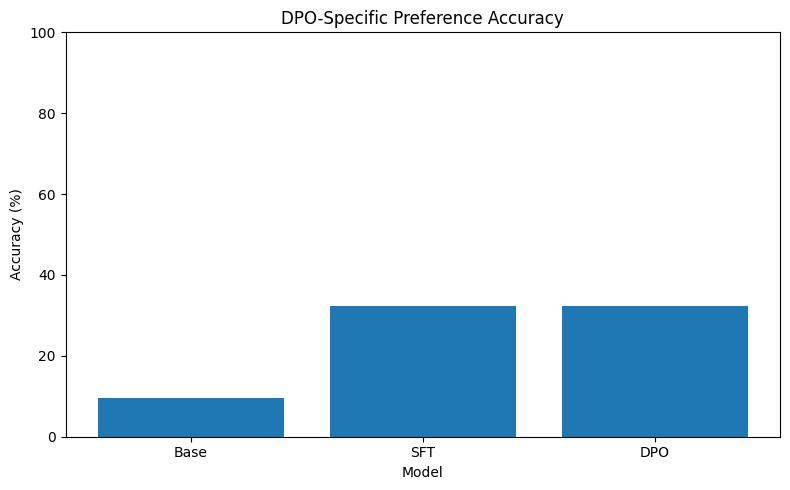

In [55]:
import matplotlib.pyplot as plt

# WHAT: Visualize preference accuracy across training stages.
# WHY: Shows whether preference alignment improved after DPO.

plt.figure(figsize=(8, 5))

plt.bar(
    preference_accuracy["Model"],
    preference_accuracy["Preference Accuracy (%)"]
)

plt.title("DPO-Specific Preference Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [56]:
# WHAT: Save detailed and summary DPO evaluation results.
# WHY: Allows us to reuse the results for the report/PPT without rerunning inference.

import os

os.makedirs("outputs", exist_ok=True)

dpo_pref_df.to_csv(
    "outputs/dpo_preference_evaluation.csv",
    index=False
)

preference_accuracy.to_csv(
    "outputs/dpo_preference_accuracy.csv",
    index=False
)

print("DPO preference evaluation saved successfully.")

DPO preference evaluation saved successfully.


In [59]:
print("FINAL EVALUATION SUMMARY \n")

print("LLM-as-a-Judge:")
display(final_scores.round(2))

print("\nDPO-Specific Preference Accuracy:")
display(preference_accuracy)

print("\nPairwise Preference:")
display(pairwise_summary)

FINAL EVALUATION SUMMARY 

LLM-as-a-Judge:


,correctness,relevance,clarity,helpfulness,overall
Base,3.65,4.22,3.59,3.47,3.61
SFT,4.08,4.45,4.10,3.98,4.10
DPO,4.12,4.49,4.16,4.06,4.14



DPO-Specific Preference Accuracy:


,Model,Preference Accuracy (%)
0,Base,9.68
1,SFT,32.26
2,DPO,32.26



Pairwise Preference:


,Comparison,Base Win %,SFT Win %,Tie %,DPO Win %
0,Base vs SFT,18.37,81.63,0.00,NaN
1,SFT vs DPO,NaN,40.82,4.08,55.10
2,Base vs DPO,18.37,NaN,0.00,81.63


# Final Evaluation Summary

## LLM-as-a-Judge

| Metric | Base | SFT | DPO |
|---|---:|---:|---:|
| Correctness | 3.65 | 4.08 | **4.12** |
| Relevance | 4.22 | 4.45 | **4.49** |
| Clarity | 3.59 | 4.10 | **4.16** |
| Helpfulness | 3.47 | 3.98 | **4.06** |
| Overall | 3.61 | 4.10 | **4.14** |

DPO achieved the highest score on all evaluated quality dimensions.

The largest improvement occurred from Base → SFT, while DPO provided a further incremental improvement.

## Pairwise Preference

- **SFT beats Base:** 81.63%
- **DPO beats SFT:** 55.10%
- **DPO beats Base:** 81.63%

This shows a strong overall preference for the post-trained models.

## DPO-Specific Preference Accuracy

- **Base:** 9.68%
- **SFT:** 32.26%
- **DPO:** 32.26%

SFT substantially improved preference accuracy over Base, while DPO did not produce an additional improvement on this particular held-out likelihood-based metric.

## Overall Conclusion

The evaluation suggests that:

**Base → SFT → DPO**

generally improves the quality and pairwise preference of generated responses.

However, the DPO-specific preference accuracy did not improve from SFT to DPO. This is an important limitation and provides a direction for further investigation using a larger held-out preference dataset and additional DPO analysis.